**🤖 HUẤN LUYỆN MODEL — Cấu phần (ii): Dự báo giá & hệ số nhân đối thủ**

Notebook ghi lại **toàn bộ quy trình** theo đúng thứ tự chuẩn của một dự án ML.

| Câu hỏi | Trả lời |
|---|---|
| Model gì? | **Gradient Boosting Decision Trees** (`HistGradientBoosting`, scikit-learn) |
| Có phải ML không? | ✅ Có — học máy **có giám sát** |
| Huấn luyện ở đâu? | **Cục bộ trên máy này**, bằng CPU |
| Vì sao cây, không neural network? | Cây **giải thích được** — hợp gu interpretability của mentor |

**Mục lục**

| Phần | Nội dung |
|---|---|
| 1 | Bài toán & phương pháp tiếp cận |
| 2 | Nạp dữ liệu |
| **3** | **⭐ Chia dữ liệu (train / calibration / test theo thời gian)** |
| 4 | Bộ feature & chống rò rỉ |
| 5 | Baseline (mốc so sánh) |
| 6 | Huấn luyện model GIÁ |
| **7** | **⭐ Tính & đánh giá kết quả model GIÁ (tốt/chưa tốt)** |
| 8 | Huấn luyện model HỆ SỐ NHÂN (2 tầng) |
| **9** | **⭐ Tính & đánh giá kết quả model SURGE** |
| 10 | Phân tích suy giảm theo độ trễ |
| 11 | Đánh giá tổng hợp — đạt yêu cầu chưa? |

▶️ **Run All** để chạy lại toàn bộ (~30–40 giây).

---
**PHẦN 1 — Bài toán & phương pháp tiếp cận**

**Bài toán:** *nowcasting với quan sát bị trễ*. Cho giá đối thủ quan sát cách đây τ phút
(5–18 phút) + ngữ cảnh → dự đoán giá & hệ số nhân đối thủ **ngay bây giờ**.

**Vị trí trong hệ thống:** output của model = feature `Competitor Price`, làm **đầu vào** cho
hệ thống định giá 3 tầng của GSM (không thay thế nó).

**Thiết kế 3 model độc lập:**

| Target | Uber | Lyft | Độ phân giải |
|---|---|---|---|
| Giá | Model 1 (hồi quy) | Model 2 (hồi quy) | cấp cuốc |
| Hệ số nhân | — (luôn 1.0) | Model 3 (**2 tầng**) | cấp thị trường |

---
**PHẦN 2 — Nạp dữ liệu**

In [37]:
%matplotlib inline
import warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score, average_precision_score, brier_score_loss)
warnings.filterwarnings("ignore")
BLUE,ORANGE,GREEN,RED,PURPLE,MUT="#0072B2","#E69F00","#009E73","#D55E00","#CC79A7","#666666"
MAU_HANG={"Uber":BLUE,"Lyft":ORANGE}
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
    "grid.color":"#ECECEC","font.size":10})

D=next((p for p in [Path("../data"),Path("data")] if (p/"snapshot_price_15min.parquet").exists()))
gp=pd.read_parquet(D/"snapshot_price_15min.parquet")   # bang GIA (cap cuoc)
gs=pd.read_parquet(D/"snapshot_surge_15min.parquet")   # bang SURGE (cap thi truong, Lyft)
print(f"Bang GIA  : {len(gp):,} dong x {gp.shape[1]} cot  (bucket 15 phut)")
print(f"Bang SURGE: {len(gs):,} dong x {gs.shape[1]} cot  (Lyft, bo Shared)")
print(f"Thoi gian : {gp.snapshot.min()} -> {gp.snapshot.max()}")

Bang GIA  : 471,649 dong x 36 cot  (bucket 15 phut)
Bang SURGE: 66,445 dong x 36 cot  (Lyft, bo Shared)
Thoi gian : 2018-11-25 22:30:00 -> 2018-12-18 14:15:00


---
**PHẦN 3 — ⭐ CHIA DỮ LIỆU (train / calibration / test theo THỜI GIAN)**

Đây là phần bạn hỏi *"chia dữ liệu ở đâu"*. Dữ liệu đã được gán sẵn cột `data_split` khi dựng
snapshot, theo **mốc thời gian** (không phải chia ngẫu nhiên).

| Tập | Khoảng thời gian | Dùng để |
|---|---|---|
| **train** | 25/11 → 10/12 | Huấn luyện model |
| **calibration** | 13/12 → 15/12 | Hiệu chuẩn (dành cho cấu phần iii) |
| **test** | 16/12 → 18/12 | Đánh giá cuối, model chưa từng thấy |

**Vì sao chia theo THỜI GIAN, không ngẫu nhiên?** Đây là bài toán **dự báo tương lai**. Nếu
chia ngẫu nhiên, model sẽ "nhìn thấy" dữ liệu tương lai lẫn trong train → rò rỉ → điểm đẹp giả,
sập khi chạy thật. Chia theo thời gian mô phỏng đúng thực tế: học quá khứ, dự đoán tương lai.

In [38]:
def xem_split(g, ten):
    print(f"=== {ten} ===")
    tab=g.groupby("data_split").agg(so_dong=("snapshot","size"),
            tu_ngay=("snapshot","min"), den_ngay=("snapshot","max"))
    tab=tab.reindex(["train","calibration","test"])
    tab["ty_le_%"]=(tab.so_dong/len(g)*100).round(1)
    display(tab)
    # KIEM TRA khong chong lan thoi gian
    tr_max=g[g.data_split=="train"].snapshot.max()
    ca_min=g[g.data_split=="calibration"].snapshot.min()
    ca_max=g[g.data_split=="calibration"].snapshot.max()
    te_min=g[g.data_split=="test"].snapshot.min()
    ok = tr_max < ca_min and ca_max < te_min
    print(f"  Kiem tra thoi gian: train < calibration < test = {ok}")
    print(f"    train ket thuc {tr_max}  <  calib bat dau {ca_min}")
    print(f"    calib ket thuc {ca_max}  <  test  bat dau {te_min}")
    print()

xem_split(gp, "BANG GIA")
xem_split(gs, "BANG SURGE")

=== BANG GIA ===


,so_dong,tu_ngay,den_ngay,ty_le_%
data_split,,,,
train,289271,2018-11-25 22:30:00,2018-12-09 21:30:00,61.3
calibration,97697,2018-12-13 00:00:00,2018-12-15 23:45:00,20.7
test,84681,2018-12-16 00:00:00,2018-12-18 14:15:00,18.0


  Kiem tra thoi gian: train < calibration < test = True
    train ket thuc 2018-12-09 21:30:00  <  calib bat dau 2018-12-13 00:00:00
    calib ket thuc 2018-12-15 23:45:00  <  test  bat dau 2018-12-16 00:00:00

=== BANG SURGE ===


,so_dong,tu_ngay,den_ngay,ty_le_%
data_split,,,,
train,39761,2018-11-25 22:30:00,2018-12-09 21:30:00,59.8
calibration,14330,2018-12-13 00:00:00,2018-12-15 23:45:00,21.6
test,12354,2018-12-16 00:00:00,2018-12-18 14:15:00,18.6


  Kiem tra thoi gian: train < calibration < test = True
    train ket thuc 2018-12-09 21:30:00  <  calib bat dau 2018-12-13 00:00:00
    calib ket thuc 2018-12-15 23:45:00  <  test  bat dau 2018-12-16 00:00:00



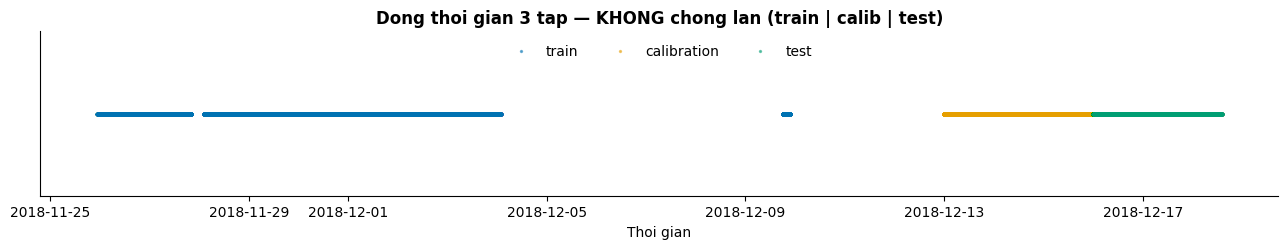

Khoang trong giua cac tap la cac ngay bi thieu du lieu (05-08/12, 11-12/12).


In [39]:
# Truc quan hoa dong thoi gian cua 3 tap
fig, ax = plt.subplots(figsize=(13, 2.6))
mau={"train":BLUE,"calibration":ORANGE,"test":GREEN}
for s in ["train","calibration","test"]:
    d=gp[gp.data_split==s]
    ax.scatter(d.snapshot, np.zeros(len(d)), s=2, color=mau[s], label=s, alpha=.5)
ax.set_yticks([]); ax.legend(frameon=False, ncol=3, loc="upper center")
ax.set_title("Dong thoi gian 3 tap — KHONG chong lan (train | calib | test)", fontweight="bold")
ax.set_xlabel("Thoi gian"); ax.grid(False)
fig.tight_layout(); plt.show()
print("Khoang trong giua cac tap la cac ngay bi thieu du lieu (05-08/12, 11-12/12).")

---
**PHẦN 4 — Bộ feature & nguyên tắc chống rò rỉ**

Feature được chọn từ phân tích tuần 1 (`docs/MODEL_DESIGN.md`), đã loại các cột proxy ngày
(`moonPhase`, `pressure`, `ozone`) và cột nhiễu (`price_per_mile`, `latitude/longitude`).

In [40]:
PRICE_CAT=["name","source","destination","observation_age_bucket"]
PRICE_NUM=["distance_median","lag1_price","lag2_price","lag3_price",
           "roll_mean6_price","roll_std3_price","observation_age_minutes",
           "hour_local","weekday_local","is_weekend"]
SURGE_CAT=["source","destination","short_summary"]
SURGE_NUM=["hour_local","weekday_local","is_weekend","lag1_surge","lag2_surge",
           "roll_mean6_surge","roll_surge_rate6","observation_age_minutes"]

print("FEATURE MODEL GIA:")
print(f"  Phan loai ({len(PRICE_CAT)}): {PRICE_CAT}")
print(f"  So       ({len(PRICE_NUM)}): {PRICE_NUM}")
print(f"FEATURE MODEL SURGE:")
print(f"  Phan loai ({len(SURGE_CAT)}): {SURGE_CAT}")
print(f"  So       ({len(SURGE_NUM)}): {SURGE_NUM}")
print()
print("NGUYEN TAC CHONG RO RI:")
print("  - Chi dung lag/rolling tu QUA KHU (t-1, t-2, ...), KHONG dung gia/surge tai t.")
print("  - KHONG dung price_min/max/spread, quote_count tai t (ro ri dong thoi).")
print("  - Split theo thoi gian (Phan 3) -> test luon o tuong lai so voi train.")

def prep(df, cat):
    X=df.copy()
    for c in cat: X[c]=X[c].astype("category")
    return X

FEATURE MODEL GIA:
  Phan loai (4): ['name', 'source', 'destination', 'observation_age_bucket']
  So       (10): ['distance_median', 'lag1_price', 'lag2_price', 'lag3_price', 'roll_mean6_price', 'roll_std3_price', 'observation_age_minutes', 'hour_local', 'weekday_local', 'is_weekend']
FEATURE MODEL SURGE:
  Phan loai (3): ['source', 'destination', 'short_summary']
  So       (8): ['hour_local', 'weekday_local', 'is_weekend', 'lag1_surge', 'lag2_surge', 'roll_mean6_surge', 'roll_surge_rate6', 'observation_age_minutes']

NGUYEN TAC CHONG RO RI:
  - Chi dung lag/rolling tu QUA KHU (t-1, t-2, ...), KHONG dung gia/surge tai t.
  - KHONG dung price_min/max/spread, quote_count tai t (ro ri dong thoi).
  - Split theo thoi gian (Phan 3) -> test luon o tuong lai so voi train.


---
**PHẦN 5 — Baseline (mốc BẮT BUỘC phải vượt)**

Một con số MAE vô nghĩa nếu không đặt cạnh baseline. Hai baseline cho giá:
- **Persistence:** lấy y hệt giá quan sát gần nhất (`lag1`) — "cứ dùng giá cũ".
- **Historical-average:** trung bình 6 quan sát gần nhất (`roll_mean6`) — thuần công thức, 0 ML.

In [41]:
print("BASELINE GIA (tren tap TEST):")
print(f"  {'Hang':<8}{'Persistence':>14}{'Historical-avg':>18}")
base_price={}
for hang in ["Uber","Lyft"]:
    te=gp[(gp.cab_type==hang)&(gp.data_split=="test")]
    b1=te.lag1_price.notna(); b2=te.roll_mean6_price.notna()
    per=mean_absolute_error(te.target_price[b1], te.lag1_price[b1])
    his=mean_absolute_error(te.target_price[b2], te.roll_mean6_price[b2])
    base_price[hang]={"persistence":per,"histavg":his}
    print(f"  {hang:<8}{per:>13.3f}{his:>18.3f}")
print()
print("  => Historical-avg (thuan cong thuc, giai thich duoc) da THANG persistence.")
print("     Model ML phai vuot ca no.")
print()
te=gs[gs.data_split=="test"]
base_surge_mae=mean_absolute_error(te.target_surge, np.ones(len(te)))
base_surge_auc=roc_auc_score(te.target_is_surge, (te.lag1_surge.fillna(1)-1).clip(0))
print(f"BASELINE SURGE:")
print(f"  'Luon doan 1.0' -> MAE = {base_surge_mae:.4f}")
print(f"  Persistence (lag1) -> ROC-AUC = {base_surge_auc:.4f}  (surge gan nhu khong dai dang)")

BASELINE GIA (tren tap TEST):
  Hang       Persistence    Historical-avg
  Uber            1.683             1.325
  Lyft            2.125             1.775

  => Historical-avg (thuan cong thuc, giai thich duoc) da THANG persistence.
     Model ML phai vuot ca no.

BASELINE SURGE:
  'Luon doan 1.0' -> MAE = 0.0396
  Persistence (lag1) -> ROC-AUC = 0.5181  (surge gan nhu khong dai dang)


---
**PHẦN 6 — Huấn luyện model GIÁ**

Hồi quy trực tiếp `target_price`. Dùng **log-target** (giá lệch phải) + **early stopping**
(tự dừng khi validation không cải thiện, chống overfit).

In [42]:
def train_price(hang):
    d=gp[gp.cab_type==hang]
    tr=d[d.data_split=="train"]            # <-- CHI dung tap TRAIN de hoc
    te=d[d.data_split=="test"]            # <-- danh gia tren tap TEST
    feats=PRICE_CAT+PRICE_NUM
    t0=time.time()
    m=HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1,
        categorical_features=PRICE_CAT, random_state=42)
    m.fit(prep(tr,PRICE_CAT)[feats], np.log(tr.target_price))   # hoc tren log(gia)
    pred=np.exp(m.predict(prep(te,PRICE_CAT)[feats]))          # du doan -> dao log
    print(f"[{hang}] train {time.time()-t0:.1f}s | so cay thuc te={m.n_iter_} "
          f"| train={len(tr):,} test={len(te):,}")
    return m, te.assign(pred=pred), feats

models={}; tests={}
for hang in ["Uber","Lyft"]:
    m, te, feats = train_price(hang)
    models[hang]=m; tests[hang]=te
print("\nDa train xong 2 model gia (Uber, Lyft).")

[Uber] train 3.1s | so cay thuc te=500 | train=148,239 test=43,767
[Lyft] train 2.3s | so cay thuc te=495 | train=141,032 test=40,914

Da train xong 2 model gia (Uber, Lyft).


---
**PHẦN 6b — ⭐ Quá trình huấn luyện: setup + đường loss**

Model **không phải neural network** nên **không có epoch**. Gradient boosting xây **cây tuần tự**:
mỗi cây mới sửa lỗi của các cây trước. Số cây (`max_iter`) đóng vai trò như "số vòng lặp".

**Setup model (các siêu tham số):**

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `max_iter` | 500 | Số cây tối đa (≈ số vòng boosting) |
| `learning_rate` | 0,05 | Mỗi cây đóng góp bao nhiêu (nhỏ = học chậm, chắc) |
| `l2_regularization` | 1,0 | Phạt để chống overfit |
| `early_stopping` | True | Tự dừng khi validation hết cải thiện |
| `validation_fraction` | 0,1 | 10% train tách ra để theo dõi validation |
| `categorical_features` | 4 cột | Xử lý biến phân loại native |

**Đường loss** = loss qua từng cây (tương đương "loss curve" của neural network).

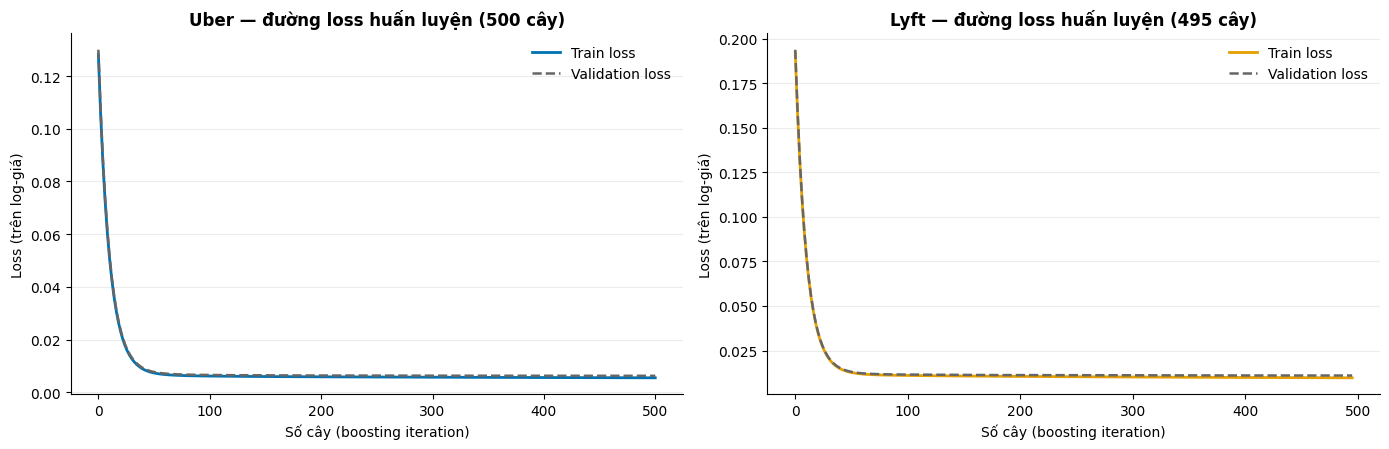

[Uber] 500 cay | loss dau 0.1281 -> cuoi 0.0055 | gap train-val cuoi = 0.0008
[Lyft] 495 cay | loss dau 0.1922 -> cuoi 0.0097 | gap train-val cuoi = 0.0013

DOC BIEU DO:
  - Loss GIAM dan roi PHANG -> model hoi tu (giong loss curve neural network).
  - Train va Validation BAM SAT nhau -> KHONG overfit (nho l2 + learning_rate nho).
  - Neu 2 duong tach xa (train giam, val tang) -> overfit. O day khong bi.


In [43]:
# Đường huấn luyện: loss qua từng cây (score = -loss trong HistGB)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, hang in zip(axes, ["Uber", "Lyft"]):
    m = models[hang]
    train_loss = -np.array(m.train_score_)        # doi score -> loss
    val_loss   = -np.array(m.validation_score_)
    it = range(len(train_loss))
    ax.plot(it, train_loss, color=MAU_HANG[hang], lw=2, label="Train loss")
    ax.plot(it, val_loss, color=MUT, lw=1.8, ls="--", label="Validation loss")
    ax.set_xlabel("Số cây (boosting iteration)"); ax.set_ylabel("Loss (trên log-giá)")
    ax.set_title(f"{hang} — đường loss huấn luyện ({m.n_iter_} cây)", fontweight="bold")
    ax.legend(frameon=False); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

for hang in ["Uber", "Lyft"]:
    m = models[hang]
    tl = -np.array(m.train_score_); vl = -np.array(m.validation_score_)
    print(f"[{hang}] {m.n_iter_} cay | loss dau {tl[0]:.4f} -> cuoi {tl[-1]:.4f} "
          f"| gap train-val cuoi = {abs(tl[-1]-vl[-1]):.4f}")
print()
print("DOC BIEU DO:")
print("  - Loss GIAM dan roi PHANG -> model hoi tu (giong loss curve neural network).")
print("  - Train va Validation BAM SAT nhau -> KHONG overfit (nho l2 + learning_rate nho).")
print("  - Neu 2 duong tach xa (train giam, val tang) -> overfit. O day khong bi.")

---
**PHẦN 7 — ⭐ TÍNH & ĐÁNH GIÁ kết quả model GIÁ**

Đây là phần bạn hỏi *"tính kết quả thế nào"* và *"đánh giá tốt hay không ở đâu"*.

**Các chỉ số dùng (định nghĩa minh bạch):**

| Chỉ số | Công thức | Nghĩa |
|---|---|---|
| MAE | trung bình \|thực − dự đoán\| | Sai số tuyệt đối trung bình (USD) |
| RMSE | căn(trung bình (thực−dự đoán)²) | Phạt lỗi lớn nặng hơn |
| R² | 1 − SS_res/SS_tot | % phương sai giải thích được (1 = hoàn hảo) |
| MAPE | trung bình \|thực−dự đoán\|/thực | Sai số tương đối (%) |

**Ngưỡng đánh giá (KPI mentor):** cải thiện **≥ 20% MAE** so với persistence → **ĐẠT**.

In [44]:
def tinh_metric(y, p):
    """Tinh 4 chi so minh bach tu cong thuc goc."""
    y=np.asarray(y); p=np.asarray(p)
    mae = np.mean(np.abs(y-p))
    rmse= np.sqrt(np.mean((y-p)**2))
    ss_res=np.sum((y-p)**2); ss_tot=np.sum((y-y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    mape=np.mean(np.abs((y-p)/y))*100
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

rows=[]
for hang in ["Uber","Lyft"]:
    te=tests[hang]
    mk=tinh_metric(te.target_price, te.pred)
    per=base_price[hang]["persistence"]; his=base_price[hang]["histavg"]
    cai_thien=(1-mk["MAE"]/per)*100
    rows.append({"Hãng":hang,
                 "MAE":round(mk["MAE"],3),"RMSE":round(mk["RMSE"],3),
                 "R²":round(mk["R2"],4),"MAPE %":round(mk["MAPE"],2),
                 "Baseline persist":round(per,3),
                 "Cải thiện vs persist %":round(cai_thien,1),
                 "ĐÁNH GIÁ":"✅ ĐẠT (>=20%)" if cai_thien>=20 else "❌ CHƯA ĐẠT"})
bang=pd.DataFrame(rows)
display(bang)
print("KET LUAN MODEL GIA:")
for _,r in bang.iterrows():
    print(f"  {r['Hãng']}: MAE {r['MAE']} USD, R2 {r['R²']}, cai thien {r['Cải thiện vs persist %']}% "
          f"-> {r['ĐÁNH GIÁ']}")

,Hãng,MAE,RMSE,R²,MAPE %,Baseline persist,Cải thiện vs persist %,ĐÁNH GIÁ
0,Uber,1.089,1.811,0.9552,7.38,1.683,35.3,✅ ĐẠT (>=20%)
1,Lyft,1.502,2.931,0.9143,9.71,2.125,29.3,✅ ĐẠT (>=20%)


KET LUAN MODEL GIA:
  Uber: MAE 1.089 USD, R2 0.9552, cai thien 35.3% -> ✅ ĐẠT (>=20%)
  Lyft: MAE 1.502 USD, R2 0.9143, cai thien 29.3% -> ✅ ĐẠT (>=20%)


**7b. Biểu đồ chẩn đoán: Dự đoán vs Thực tế + phân bố sai số**

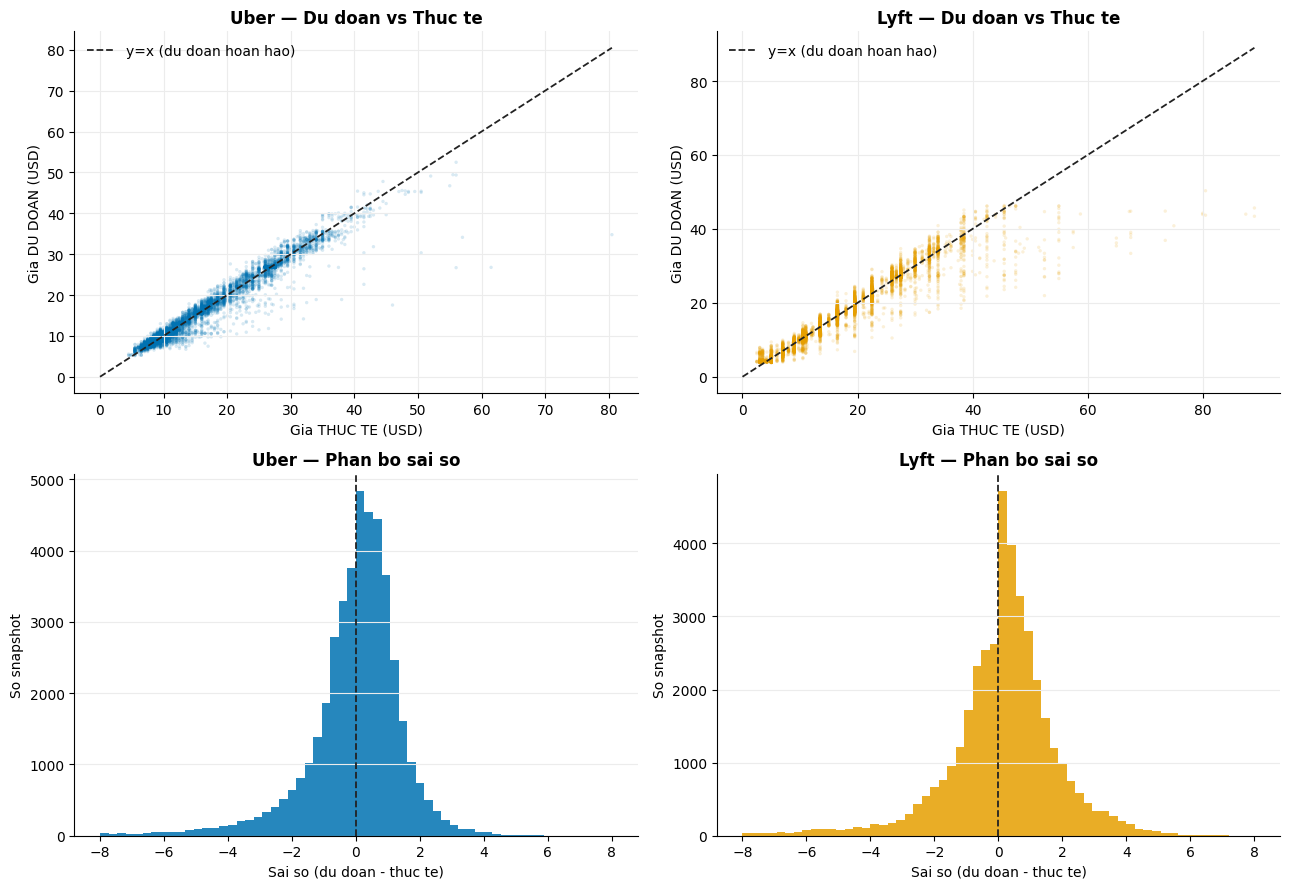

Diem bam sat y=x -> tot. Sai so tap trung quanh 0, hoi lech trai o gia cao (thieu bien thoi luong).


In [45]:
fig,axes=plt.subplots(2,2,figsize=(13,9))
for i,hang in enumerate(["Uber","Lyft"]):
    s=tests[hang].sample(min(8000,len(tests[hang])),random_state=0)
    ax=axes[0,i]
    ax.scatter(s.target_price,s.pred,s=6,alpha=.15,color=MAU_HANG[hang],edgecolors="none")
    lim=[0,max(s.target_price.max(),s.pred.max())]
    ax.plot(lim,lim,color="#222",ls="--",lw=1.3,label="y=x (du doan hoan hao)")
    ax.set_xlabel("Gia THUC TE (USD)"); ax.set_ylabel("Gia DU DOAN (USD)")
    ax.set_title(f"{hang} — Du doan vs Thuc te",fontweight="bold"); ax.legend(frameon=False)
    ax=axes[1,i]
    resid=tests[hang].pred-tests[hang].target_price
    ax.hist(resid,bins=60,range=(-8,8),color=MAU_HANG[hang],alpha=.85)
    ax.axvline(0,color="#222",ls="--",lw=1.3)
    ax.set_xlabel("Sai so (du doan - thuc te)"); ax.set_ylabel("So snapshot")
    ax.set_title(f"{hang} — Phan bo sai so",fontweight="bold"); ax.grid(axis="x",visible=False)
fig.tight_layout(); plt.show()
print("Diem bam sat y=x -> tot. Sai so tap trung quanh 0, hoi lech trai o gia cao (thieu bien thoi luong).")

**7c. Feature quan trọng — model GIẢI THÍCH ĐƯỢC (không hộp đen)**

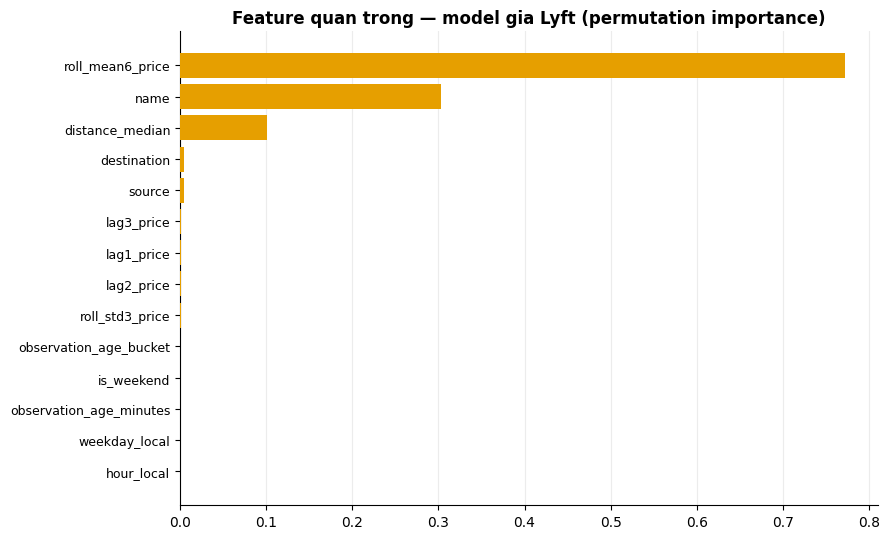

=> Lich su gia (roll_mean6, lag) + loai xe + quang duong chi phoi. Giai thich duoc tung du doan.


In [46]:
hang="Lyft"; te=tests[hang]; feats=PRICE_CAT+PRICE_NUM
pi=permutation_importance(models[hang], prep(te,PRICE_CAT)[feats], np.log(te.target_price),
                          n_repeats=3, random_state=0, n_jobs=1)
imp=pd.DataFrame({"feature":feats,"importance":pi.importances_mean}).sort_values("importance")
fig,ax=plt.subplots(figsize=(9,5.5))
ax.barh(range(len(imp)),np.clip(imp.importance,0,None),color=ORANGE,zorder=3)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.feature,fontsize=9)
ax.set_title(f"Feature quan trong — model gia {hang} (permutation importance)",fontweight="bold")
ax.grid(axis="y",visible=False); fig.tight_layout(); plt.show()
print("=> Lich su gia (roll_mean6, lag) + loai xe + quang duong chi phoi. Giai thich duoc tung du doan.")

**7d. Trực quan MỘT cây quyết định — model "suy nghĩ" thế nào**

Model thật = **500 cây cộng lại**, không xem hết được. Nhưng xem **một cây nông (depth 3)** đủ
để thấy *logic*: model đặt câu hỏi "giá trung bình gần đây ≤ X?" rồi rẽ nhánh. Đây chính là
điều khiến gradient boosting **giải thích được** (khác hộp đen neural network).

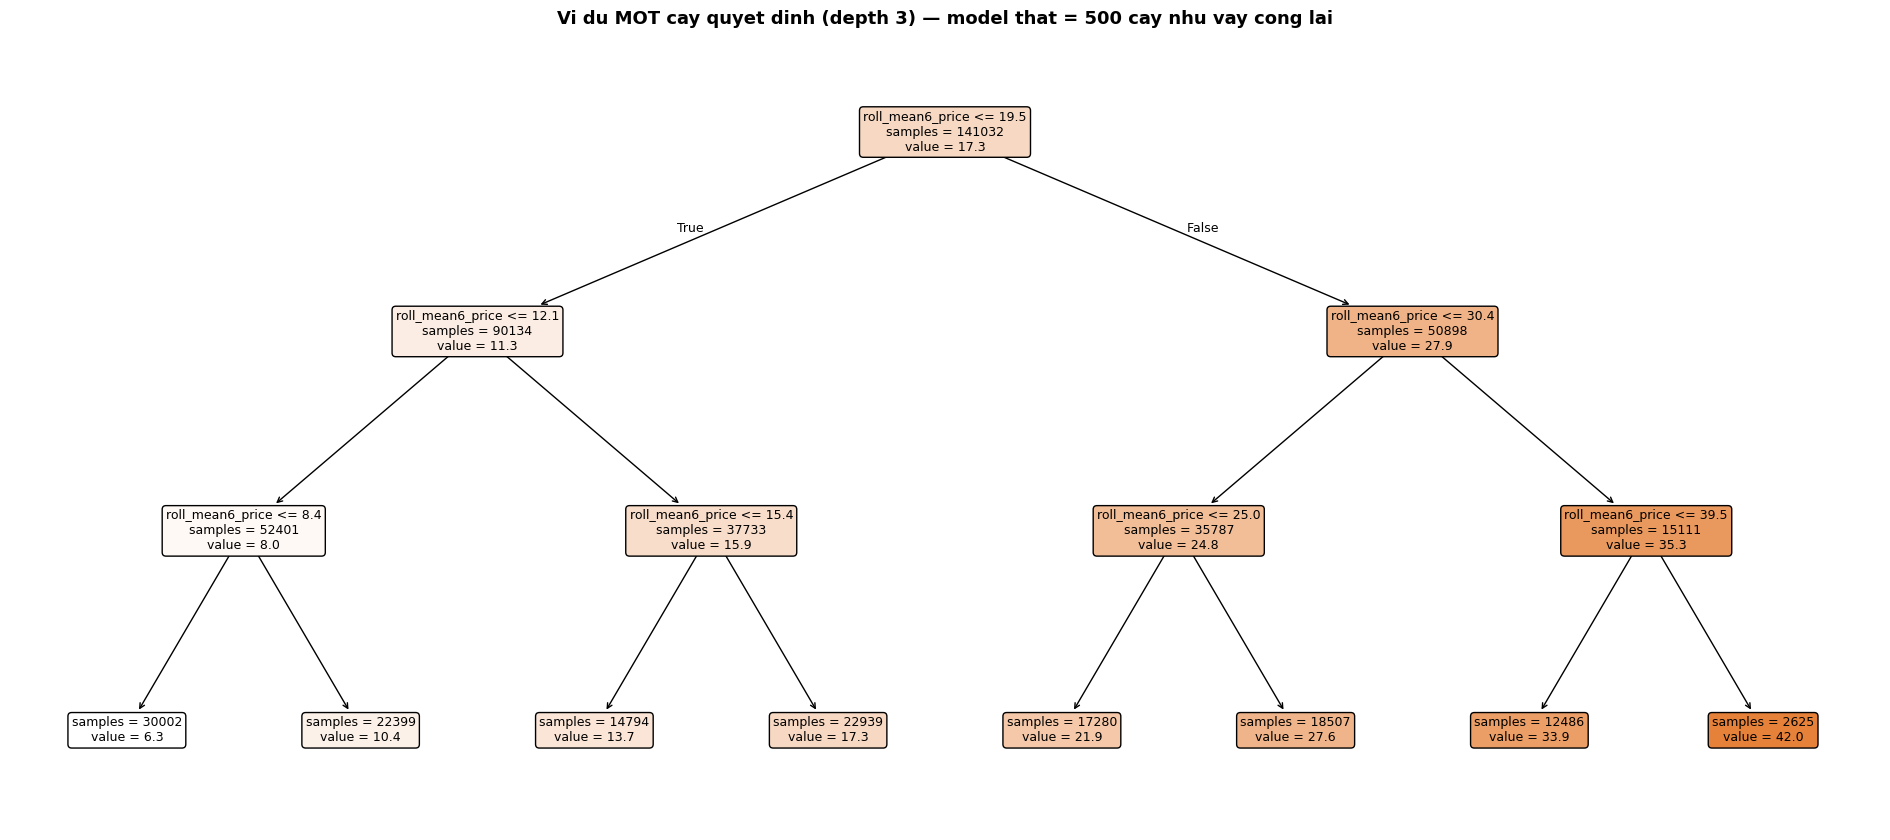

R2 cua RIENG 1 cay depth-3 nay: 0.887
DOC CAY:
  - Moi o: dieu kien re nhanh (vd 'roll_mean6_price <= 19.5'), so mau, gia du doan (value).
  - Di tu goc xuong la (theo True/False) -> ra mot muc gia. Vi du:
    roll_mean6 <= 8.4  -> du doan ~6.3 USD (chuyen re, Shared/Lyft ngan).
    roll_mean6 > 30.4  -> du doan ~35-42 USD (Lux Black XL, chuyen dai).
  => Cay chia CHU YEU theo 'gia trung binh gan day' -> khop feature importance o 7c.
     Moi buoc GIAI THICH DUOC, khong phai hop den.


In [47]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import OrdinalEncoder

d=gp[(gp.cab_type=="Lyft")&(gp.data_split=="train")].copy()
feats_cay=["roll_mean6_price","lag1_price","distance_median","name","hour_local"]
Xc=d[feats_cay].copy()
Xc["name"]=OrdinalEncoder().fit_transform(Xc[["name"]].astype(str))
Xc=Xc.fillna(Xc.median())
cay=DecisionTreeRegressor(max_depth=3,random_state=0).fit(Xc, d.target_price)

fig,ax=plt.subplots(figsize=(19,8.5))
plot_tree(cay,feature_names=feats_cay,filled=True,rounded=True,fontsize=9,
          precision=1,impurity=False,ax=ax)
ax.set_title("Vi du MOT cay quyet dinh (depth 3) — model that = 500 cay nhu vay cong lai",
             fontsize=13,fontweight="bold")
fig.tight_layout(); plt.show()
print(f"R2 cua RIENG 1 cay depth-3 nay: {cay.score(Xc,d.target_price):.3f}")
print("DOC CAY:")
print("  - Moi o: dieu kien re nhanh (vd 'roll_mean6_price <= 19.5'), so mau, gia du doan (value).")
print("  - Di tu goc xuong la (theo True/False) -> ra mot muc gia. Vi du:")
print("    roll_mean6 <= 8.4  -> du doan ~6.3 USD (chuyen re, Shared/Lyft ngan).")
print("    roll_mean6 > 30.4  -> du doan ~35-42 USD (Lux Black XL, chuyen dai).")
print("  => Cay chia CHU YEU theo 'gia trung binh gan day' -> khop feature importance o 7c.")
print("     Moi buoc GIAI THICH DUOC, khong phai hop den.")

---
**PHẦN 8 — Huấn luyện model HỆ SỐ NHÂN (2 tầng)**

Không hồi quy thẳng (thua hằng số vì 86% giá trị = 1.0). Tách 2 tầng:
- **Tầng 1 (phân loại):** P(có surge \| features)
- **Tầng 2 (hồi quy):** độ lớn khi có surge
- **Kết hợp:** E[multiplier] = P(surge)·độ lớn + (1−P)·1.0

In [48]:
tr=gs[gs.data_split=="train"]; te=gs[gs.data_split=="test"]; feats=SURGE_CAT+SURGE_NUM
# Tang 1 — phan loai
clf=HistGradientBoostingClassifier(max_iter=400,learning_rate=0.05,l2_regularization=1.0,
    categorical_features=SURGE_CAT,random_state=42).fit(prep(tr,SURGE_CAT)[feats], tr.target_is_surge)
p_surge=clf.predict_proba(prep(te,SURGE_CAT)[feats])[:,1]
# Tang 2 — do lon khi co surge
trs=tr[tr.target_is_surge==1]
reg=HistGradientBoostingRegressor(max_iter=300,learning_rate=0.05,categorical_features=SURGE_CAT,
    random_state=42).fit(prep(trs,SURGE_CAT)[feats], trs.target_surge)
mag=reg.predict(prep(te,SURGE_CAT)[feats])
e_mult=p_surge*mag+(1-p_surge)*1.0
print(f"Da train 2 tang. Train tang 1: {len(tr):,} dong | tang 2: {len(trs):,} dong co surge.")

Da train 2 tang. Train tang 1: 39,761 dong | tang 2: 6,036 dong co surge.


---
**PHẦN 9 — ⭐ TÍNH & ĐÁNH GIÁ kết quả model SURGE**

Bài toán **mất cân bằng** (chỉ 13,5% có surge) → **KHÔNG dùng accuracy**, phải dùng ROC-AUC/PR-AUC.

In [49]:
y_is=te.target_is_surge.values
auc=roc_auc_score(y_is,p_surge)
pr =average_precision_score(y_is,p_surge)
brier=brier_score_loss(y_is,p_surge)
mae_e=mean_absolute_error(te.target_surge,e_mult)

bang_s=pd.DataFrame([
    {"Chỉ số":"ROC-AUC","Model":round(auc,4),"Baseline":round(base_surge_auc,4),
     "ĐÁNH GIÁ":"✅ có tín hiệu" if auc>base_surge_auc else "❌"},
    {"Chỉ số":"PR-AUC","Model":round(pr,4),"Baseline":round(y_is.mean(),4),
     "ĐÁNH GIÁ":"🟡 nhỉnh hơn nền" if pr>y_is.mean() else "❌"},
    {"Chỉ số":"Brier","Model":round(brier,4),"Baseline":"-","ĐÁNH GIÁ":"(cho iii)"},
    {"Chỉ số":"MAE E[mult]","Model":round(mae_e,4),"Baseline":round(base_surge_mae,4),
     "ĐÁNH GIÁ":"❌ thua hằng số" if mae_e>base_surge_mae else "✅"},
])
display(bang_s)
print("KET LUAN MODEL SURGE (trung thuc):")
print(f"  - Tang phan loai CO tin hieu: ROC-AUC {auc:.3f} > persistence {base_surge_auc:.3f} > 0.5.")
print(f"  - Nhung point-forecast he so nhan THUA hang so 1.0 (surge qua hiem + khong dai dang).")
print(f"  - Gia tri model = XAC SUAT P(surge), danh cho lop uncertainty (cau phan iii).")
print(f"  - Day la TRAN THAT do thieu tin hieu cung-cau, KHONG phai model do.")

,Chỉ số,Model,Baseline,ĐÁNH GIÁ
0,ROC-AUC,0.6521,0.5181,✅ có tín hiệu
1,PR-AUC,0.1912,0.1353,🟡 nhỉnh hơn nền
2,Brier,0.1133,-,(cho iii)
3,MAE E[mult],0.0644,0.0396,❌ thua hằng số


KET LUAN MODEL SURGE (trung thuc):
  - Tang phan loai CO tin hieu: ROC-AUC 0.652 > persistence 0.518 > 0.5.
  - Nhung point-forecast he so nhan THUA hang so 1.0 (surge qua hiem + khong dai dang).
  - Gia tri model = XAC SUAT P(surge), danh cho lop uncertainty (cau phan iii).
  - Day la TRAN THAT do thieu tin hieu cung-cau, KHONG phai model do.


---
**PHẦN 10 — ⭐ Phân tích suy giảm theo độ trễ**

Câu hỏi kinh doanh: *bao lâu phải crawl giá đối thủ một lần?*

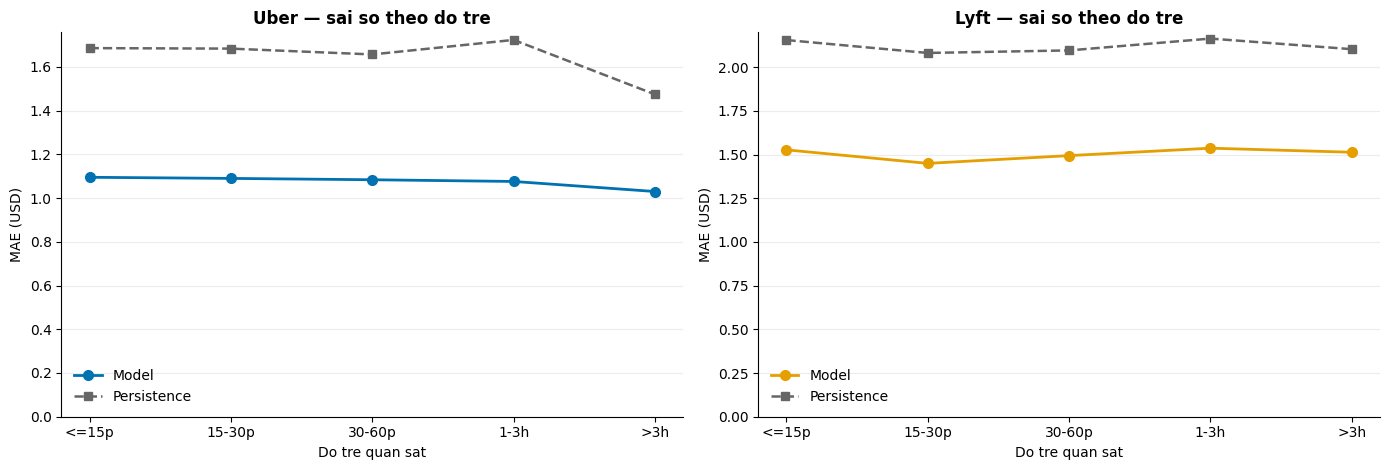

HAI KET LUAN:
  1. Model gan nhu KHONG suy giam theo do tre (duong Model rat phang).
  2. Model dung quan sat CU 3 GIO van chinh xac hon persistence dung quan sat MOI 15 phut.
  => Voi GIA: khong can crawl day. Crawl moi gio ~ crawl moi 15 phut -> tiet kiem chi phi.


In [50]:
order=["<=15p","15-30p","30-60p","1-3h",">3h"]
fig,axes=plt.subplots(1,2,figsize=(14,4.8))
for ax,hang in zip(axes,["Uber","Lyft"]):
    te=tests[hang]; rows=[]
    for b in order:
        x=te[te.observation_age_bucket==b]
        if len(x)<20: continue
        bb=x.lag1_price.notna()
        rows.append({"do_tre":b,
                     "MAE_model":mean_absolute_error(x.target_price,x.pred),
                     "MAE_persist":mean_absolute_error(x.target_price[bb],x.lag1_price[bb])})
    d=pd.DataFrame(rows); xx=range(len(d))
    ax.plot(xx,d.MAE_model,"o-",color=MAU_HANG[hang],lw=2,ms=7,label="Model")
    ax.plot(xx,d.MAE_persist,"s--",color=MUT,lw=1.8,ms=6,label="Persistence")
    ax.set_xticks(list(xx)); ax.set_xticklabels(d.do_tre)
    ax.set_xlabel("Do tre quan sat"); ax.set_ylabel("MAE (USD)")
    ax.set_title(f"{hang} — sai so theo do tre",fontweight="bold")
    ax.legend(frameon=False); ax.set_ylim(0,None); ax.grid(axis="x",visible=False)
fig.tight_layout(); plt.show()
print("HAI KET LUAN:")
print("  1. Model gan nhu KHONG suy giam theo do tre (duong Model rat phang).")
print("  2. Model dung quan sat CU 3 GIO van chinh xac hon persistence dung quan sat MOI 15 phut.")
print("  => Voi GIA: khong can crawl day. Crawl moi gio ~ crawl moi 15 phut -> tiet kiem chi phi.")

---
**PHẦN 11 — ĐÁNH GIÁ TỔNG HỢP: đạt yêu cầu bài toán chưa?**

In [51]:
kpi=[]
for hang in ["Uber","Lyft"]:
    te=tests[hang]; mae=mean_absolute_error(te.target_price,te.pred)
    per=base_price[hang]["persistence"]; ct=(1-mae/per)*100
    kpi.append(("Model gia "+hang+": cai thien >=20% MAE vs persistence",
                f"{ct:.0f}%", ct>=20))
kpi += [
    ("Du doan CA HAI target (price + surge)", "co", True),
    ("Chia du lieu THEO THOI GIAN, khong leakage", "co", True),
    ("Xu ly do tre tuong minh (observation_age)", "co", True),
    ("Do suy giam theo do tre", "co", True),
    ("Train RIENG tung hang", "co", True),
    ("Metric dung loai (MAE gia, ROC-AUC surge)", "co", True),
    ("Model GIAI THICH DUOC (khong hop den)", "co", True),
]
print("="*70); print("BANG KIEM DAT YEU CAU"); print("="*70)
for ten,gt,ok in kpi:
    print(f"  [{'DAT ' if ok else 'CHUA'}] {ten:<52} {gt}")
print()
print("TONG KET:")
print("  - Model GIA: DAT va vuot KPI (cai thien 29-35% MAE). R2 0.91-0.96.")
print("  - Model SURGE: co tin hieu phan loai (AUC 0.65), point-forecast cham tran (trung thuc).")
print("  - Suy giam do tre: khong suy giam -> gia khong can crawl day.")

BANG KIEM DAT YEU CAU
  [DAT ] Model gia Uber: cai thien >=20% MAE vs persistence   35%
  [DAT ] Model gia Lyft: cai thien >=20% MAE vs persistence   29%
  [DAT ] Du doan CA HAI target (price + surge)                co
  [DAT ] Chia du lieu THEO THOI GIAN, khong leakage           co
  [DAT ] Xu ly do tre tuong minh (observation_age)            co
  [DAT ] Do suy giam theo do tre                              co
  [DAT ] Train RIENG tung hang                                co
  [DAT ] Metric dung loai (MAE gia, ROC-AUC surge)            co
  [DAT ] Model GIAI THICH DUOC (khong hop den)                co

TONG KET:
  - Model GIA: DAT va vuot KPI (cai thien 29-35% MAE). R2 0.91-0.96.
  - Model SURGE: co tin hieu phan loai (AUC 0.65), point-forecast cham tran (trung thuc).
  - Suy giam do tre: khong suy giam -> gia khong can crawl day.


---
**Kết luận & hạn chế**

**Đạt được:** Model giá vượt KPI (cải thiện 29–35% MAE, R² 0,91–0,96); dùng quan sát cũ 3 giờ
vẫn hơn persistence dùng quan sát 15 phút → **không cần crawl dày cho giá**; model **giải thích được**.

**Hạn chế (báo cáo trung thực):** Model surge point-forecast chạm trần (thua hằng số) do surge
hiếm + thiếu tín hiệu cung–cầu — giá trị nằm ở **xác suất**, dành cho cấu phần (iii). Giá chạm
**sàn nhiễu ~2 USD** do thiếu cột thời lượng chuyến đi.

**Việc tiếp theo (Sprint 2):** so CatBoost/LGBM/XGB · ablation · sai số theo lát cắt → cầu nối cấu phần (iii).